# Sentiment Analysis on Customer Reviews

## Imports

In [1]:
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
import re

In [2]:
# Download necessary NLTK resources
nltk.download('vader_lexicon')
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/jaiharishan/nltk_data...
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/jaiharishan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jaiharishan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Load Dataset

In [ ]:
# Load the dataset
file_path = '../data/olist_order_reviews_dataset.csv'  # Replace with your actual file path
df = pd.read_csv(file_path)

# Display the first few rows to understand the data structure
df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [4]:
# Check for missing values
print("Missing values in each column:")
df.isnull().sum()

Missing values in each column:


review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [5]:
# Basic info about the dataset
print(f"Number of reviews: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

Number of reviews: 99224
Columns: ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']


## Preprocess text data

In [ ]:

def preprocess_text(text):
    """Clean and preprocess text data"""
    if isinstance(text, str):
        # Convert to lowercase
        text = text.lower()
        # Remove special characters and numbers
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        # Remove extra whitespaces
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    return ""

# Apply preprocessing to review comments
df['processed_title'] = df['review_comment_title'].apply(preprocess_text)
df['processed_message'] = df['review_comment_message'].apply(preprocess_text)

## Apply Sentiment Analysis

In [7]:
# Initialize the VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

In [12]:
# Apply sentiment analysis to review comments
df['title_sentiment'] = df['review_comment_title'].apply(
    lambda x: sia.polarity_scores(str(x)) if pd.notna(x) else {'compound': 0}
).apply(lambda x: x['compound'])

df['message_sentiment'] = df['review_comment_message'].apply(
    lambda x: sia.polarity_scores(str(x)) if pd.notna(x) else {'compound': 0}
).apply(lambda x: x['compound'])

# Combine title and message sentiment (weighted average)
df['combined_sentiment'] = (df['title_sentiment'] * 0.1) + (df['message_sentiment'] * 0.9)

In [13]:
# Categorize sentiment
df['sentiment_category'] = pd.cut(
    df['combined_sentiment'],
    bins=[-1, -0.5, -0.1, 0.1, 0.5, 1],
    labels=['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive']
)

In [14]:
# Display sentiment distribution
print("\nSentiment distribution:")
df['sentiment_category'].value_counts()



Sentiment distribution:


sentiment_category
Neutral          91578
Negative          4464
Very Positive     1556
Positive          1506
Very Negative      120
Name: count, dtype: int64

## Visualization

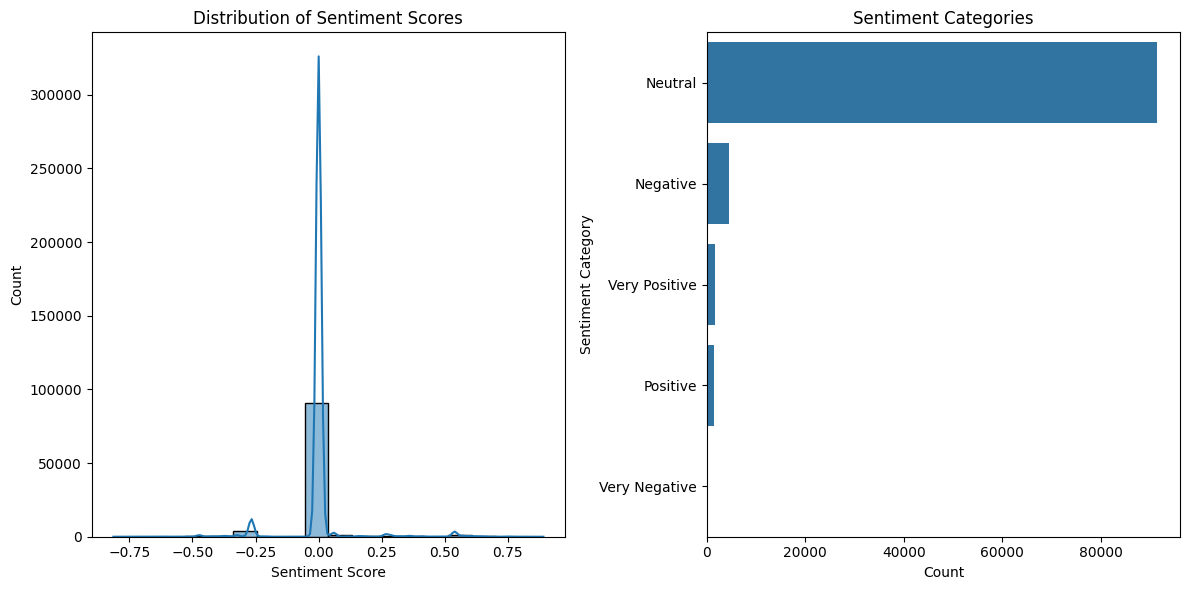

In [15]:
# Visualize sentiment distribution
plt.figure(figsize=(12, 6))

# Sentiment distribution
plt.subplot(1, 2, 1)
sns.histplot(df['combined_sentiment'], kde=True)
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Count')

# Sentiment categories
plt.subplot(1, 2, 2)
sns.countplot(y='sentiment_category', data=df, order=df['sentiment_category'].value_counts().index)
plt.title('Sentiment Categories')
plt.xlabel('Count')
plt.ylabel('Sentiment Category')

plt.tight_layout()
plt.show()

### WordCloud

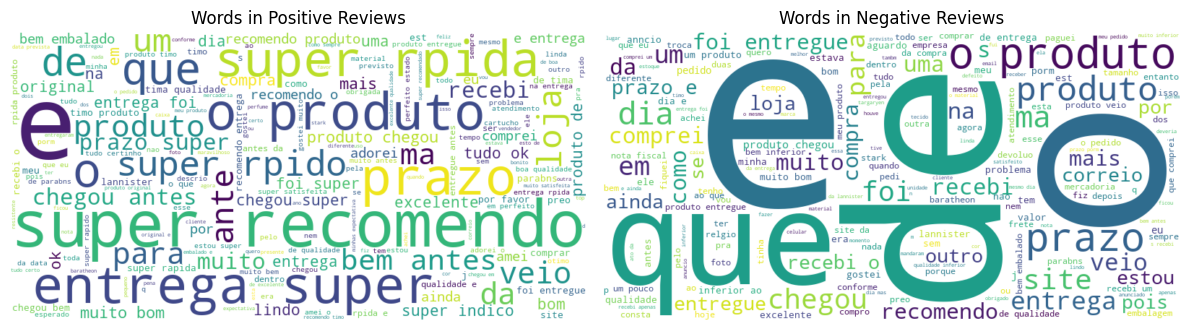

In [16]:
# Create word clouds for different sentiment categories
# Get positive reviews
positive_reviews = ' '.join(df[df['combined_sentiment'] > 0.3]['processed_message'].dropna())

# Get negative reviews
negative_reviews = ' '.join(df[df['combined_sentiment'] < -0.3]['processed_message'].dropna())

# Create word clouds
plt.figure(figsize=(12, 6))

if positive_reviews:
    plt.subplot(1, 2, 1)
    wordcloud_positive = WordCloud(width=800, height=400, background_color='white').generate(positive_reviews)
    plt.imshow(wordcloud_positive, interpolation='bilinear')
    plt.title('Words in Positive Reviews')
    plt.axis('off')

if negative_reviews:
    plt.subplot(1, 2, 2)
    wordcloud_negative = WordCloud(width=800, height=400, background_color='white').generate(negative_reviews)
    plt.imshow(wordcloud_negative, interpolation='bilinear')
    plt.title('Words in Negative Reviews')
    plt.axis('off')

plt.tight_layout()
plt.show()

### Sentiment VS Review Scores

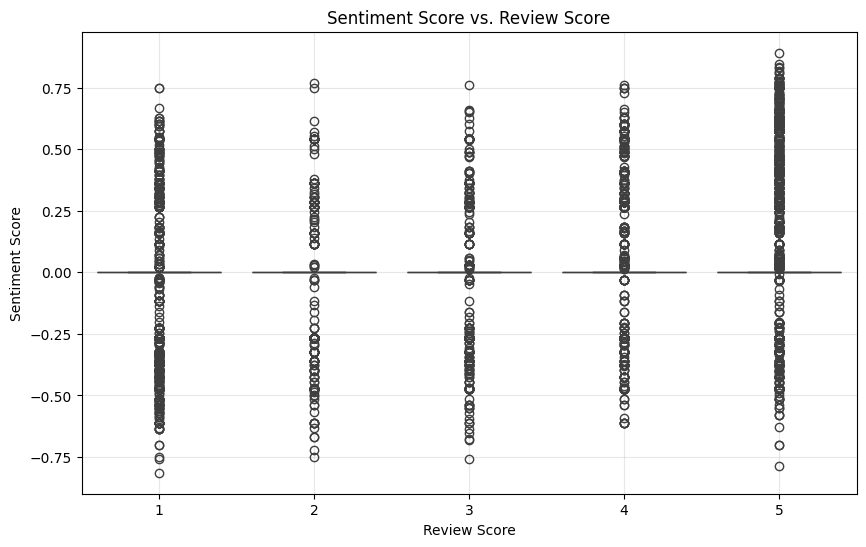

In [17]:
# Compare sentiment with review scores
plt.figure(figsize=(10, 6))
sns.boxplot(x='review_score', y='combined_sentiment', data=df)
plt.title('Sentiment Score vs. Review Score')
plt.xlabel('Review Score')
plt.ylabel('Sentiment Score')
plt.grid(True, alpha=0.3)
plt.show()

### Correlation

In [18]:
# Calculate correlation
correlation = df[['review_score', 'combined_sentiment']].corr().iloc[0, 1]
print(f"Correlation between review score and sentiment: {correlation:.4f}")

Correlation between review score and sentiment: 0.1185


### Common Phrases

In [19]:
# Extract common phrases/keywords for positive reviews
def extract_common_phrases(df, sentiment_type='positive', top_n=10):
    """Extract most common words/phrases for positive or negative reviews"""
    if sentiment_type == 'positive':
        text_data = df[df['combined_sentiment'] > 0.3]['processed_message'].dropna()
    else:
        text_data = df[df['combined_sentiment'] < -0.3]['processed_message'].dropna()
    
    # Use CountVectorizer to get common n-grams
    vectorizer = CountVectorizer(stop_words='english', ngram_range=(1, 2))
    X = vectorizer.fit_transform(text_data)
    
    # Get most common words/phrases
    words = vectorizer.get_feature_names_out()
    counts = X.sum(axis=0).A1
    
    # Create DataFrame with word frequencies
    freq_df = pd.DataFrame({'word': words, 'count': counts})
    freq_df = freq_df.sort_values('count', ascending=False).head(top_n)
    
    return freq_df

# Extract common phrases for positive reviews
positive_phrases = extract_common_phrases(df, sentiment_type='positive')
print("Top 10 positive words/phrases:")
positive_phrases

# Extract common phrases for negative reviews
negative_phrases = extract_common_phrases(df, sentiment_type='negative')
print("Top 10 negative words/phrases:")
negative_phrases

Top 10 positive words/phrases:
Top 10 negative words/phrases:


,word,count
10445,produto,702
10981,que,513
10029,prazo,430
5975,foi,251
2093,com,245
13497,um,234
3737,dia,221
11448,recebi,217
4593,entrega,208
1876,chegou,204


### Average Sentiment Over Time

/var/folders/sw/n5q9z8253lv92n2jmyb_p2zw0000gn/T/ipykernel_20847/2998191949.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sentiment = df.set_index('review_creation_date')['combined_sentiment'].resample('M').mean()


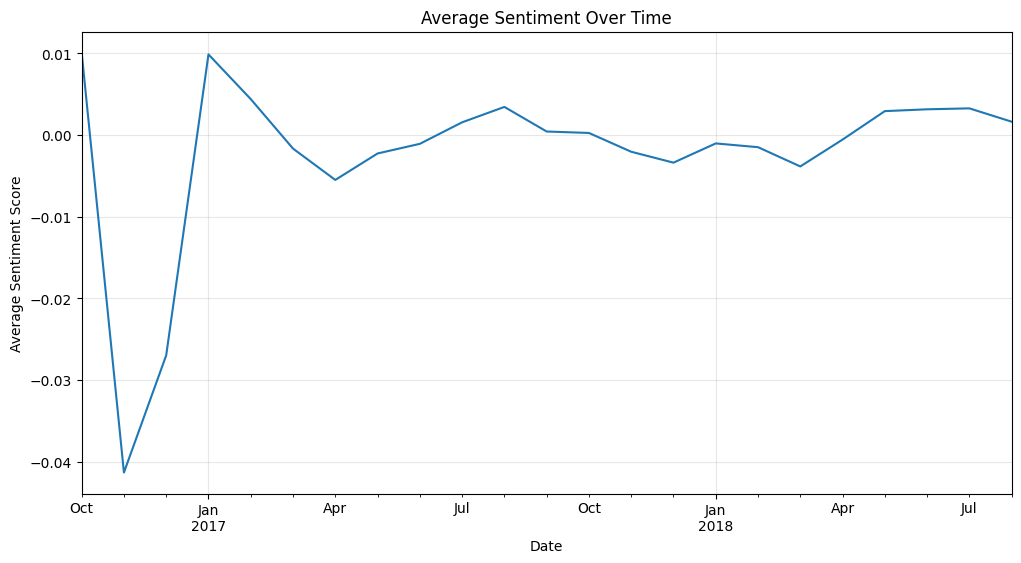

In [20]:
# Analysis over time
# Convert review_creation_date to datetime
df['review_creation_date'] = pd.to_datetime(df['review_creation_date'])

# Group by month and calculate average sentiment
monthly_sentiment = df.set_index('review_creation_date')['combined_sentiment'].resample('M').mean()

# Plot
plt.figure(figsize=(12, 6))
monthly_sentiment.plot()
plt.title('Average Sentiment Over Time')
plt.xlabel('Date')
plt.ylabel('Average Sentiment Score')
plt.grid(True, alpha=0.3)
plt.show()

### Response Time VS Sentiment

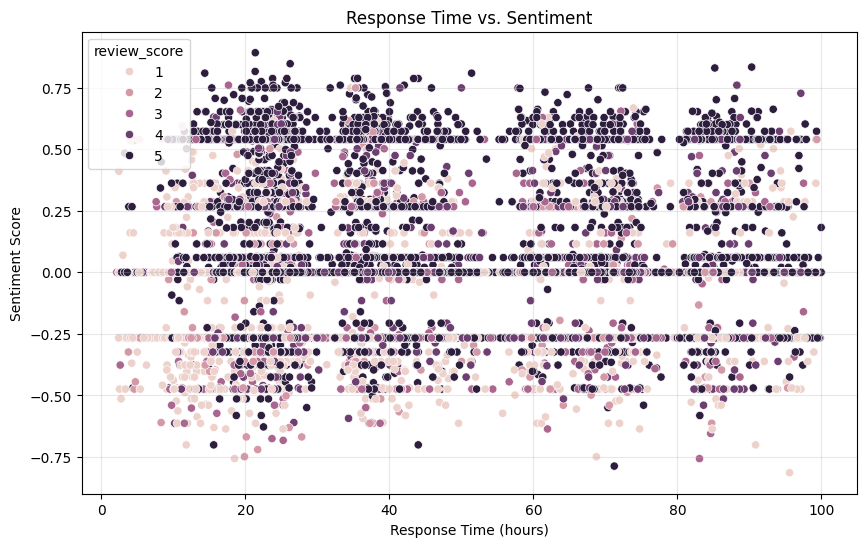

Correlation between response time and sentiment: 0.0026


In [21]:
# Check response times and their relation to sentiment
if 'review_answer_timestamp' in df.columns:
    # Calculate response time (if both dates are available)
    df['review_answer_timestamp'] = pd.to_datetime(df['review_answer_timestamp'])
    
    # Calculate response time in hours (only for answered reviews)
    mask = (~df['review_answer_timestamp'].isna()) & (~df['review_creation_date'].isna())
    df.loc[mask, 'response_time_hours'] = (df.loc[mask, 'review_answer_timestamp'] - df.loc[mask, 'review_creation_date']).dt.total_seconds() / 3600
    
    # Visualize response time vs sentiment
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='response_time_hours', y='combined_sentiment', hue='review_score', data=df[df['response_time_hours'] < 100])  # Filtering outliers
    plt.title('Response Time vs. Sentiment')
    plt.xlabel('Response Time (hours)')
    plt.ylabel('Sentiment Score')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Check if longer response times correlate with negative sentiment
    print(f"Correlation between response time and sentiment: {df[['response_time_hours', 'combined_sentiment']].corr().iloc[0, 1]:.4f}")